# Step 24 — MJO RMM from Daily-Averaged ERA5 (WH04 reproduction)
**Project:** ENSO-BSISO Self-Supervised Learning — MJO Extension  
**Author:** Jiayi (jh9141@nyu.edu)

Computes our own multivariate EOF (RMM1/RMM2) from the daily-mean `X_MJO.npy` produced by nb13, and reproduces the diagnostic figures of **Wheeler & Hendon (2004)** so we can see *what happened to our data and labels* after the daily-average migration.

Two EOF pipelines, both on the already-WH04-preprocessed `X_MJO` (channels `[u850, OLR, u200]`, 15°S–15°N meridional average, 3-harmonic annual cycle removed, 120-day running mean removed, global-std normalized):

| Pipeline | EOF basis fit on | Projected onto |
|----------|------------------|----------------|
| **A — own EOF** | full record 1979–2023 | full record |
| **B — WH04-style** | calibration base 1979–2001 | full record |

**Figures (WH04 analogs):**
- **Fig A** — variance spectrum (WH04 Fig 1): PC1≈12.8%, PC2≈12.2% benchmark
- **Fig B** — EOF1/EOF2 longitude structure (WH04 Fig 2): quadrature → eastward propagation
- **Fig C** — PC1×PC2 lag-correlation (WH04 Fig 3): peak ≈ +10 d
- **Fig D** — RMM power spectra (WH04 Fig 4): 30–80 day peak
- **Fig E** — RMM1–RMM2 phase diagram (WH04 Fig 7): 8 phases + unit circle, ours vs BoM
- **Fig F** — RMM timeseries: ours (solid) vs BoM (dashed), full-period + zoomed years
- **Fig G** — longitude-profile phase composites (substitute for WH04 Fig 8 — we lack a latitude axis)

**Inputs (from `MJO/data/processed/`):** `X_MJO.npy`, `labels_aligned_mjo.csv`, `longitudes_mjo.npy`, `norm_stats_mjo.json`

**Outputs (to `MJO/data/processed/`):** `mjo_rmm_own_pcs.npy`, `mjo_rmm_wh04_pcs.npy`, `mjo_eof_patterns.npy`, `mjo_rmm_metadata.json`, + 7 PNG figures

---

## Cell 1 — Mount Drive + Load Inputs + Pre-flight Freshness Check

Asserts that `X_MJO.npy` is **newer** than the raw `OLR_MJO_*.nc` files — i.e. nb13 has been rerun on the daily-mean data. If not, aborts so we don't silently analyze stale snapshot-derived arrays.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR   = '/content/drive/MyDrive/BSISO_SSL_Project'
MJO_DIR       = f'{PROJECT_DIR}/MJO'
RAW_DIR       = f'{MJO_DIR}/data/raw'
PROCESSED_DIR = f'{MJO_DIR}/data/processed'

X_path   = f'{PROCESSED_DIR}/X_MJO.npy'
y_path   = f'{PROCESSED_DIR}/labels_aligned_mjo.csv'
lon_path = f'{PROCESSED_DIR}/longitudes_mjo.npy'

X_MJO  = np.load(X_path)                       # (N, 3, 1, 180), channels [u850, OLR, u200]
labels = pd.read_csv(y_path, parse_dates=['date'])
lons   = np.load(lon_path)                      # (180,)

CHANNELS = ['u850', 'OLR', 'u200']
N = X_MJO.shape[0]
print(f'X_MJO:  {X_MJO.shape}  ({X_MJO.nbytes/1e6:.1f} MB)')
print(f'labels: {len(labels)} rows  ({labels.date.min().date()} .. {labels.date.max().date()})')
print(f'lons:   {lons.shape}  [{lons.min():.1f} .. {lons.max():.1f}]')

# --- consistency asserts ---
assert len(labels) == N, f'X_MJO N={N} != labels {len(labels)}'
for col in ['rmm1', 'rmm2', 'phase', 'amplitude', 'enso_category']:
    assert col in labels.columns, f'labels missing column {col}'

# --- pre-flight freshness check ---
raw_olr = [f'{RAW_DIR}/{f}' for f in os.listdir(RAW_DIR)
           if f.startswith('OLR_MJO_') and f.endswith('.nc')]
x_mtime = os.path.getmtime(X_path)
if raw_olr:
    raw_mtime = max(os.path.getmtime(f) for f in raw_olr)
    dh = (x_mtime - raw_mtime) / 3600
    print(f'\nX_MJO mtime - newest raw OLR mtime = {dh:+.1f} h')
    if dh < 0:
        raise RuntimeError(
            'X_MJO.npy is OLDER than the raw OLR .nc files. '
            'Re-run nb13 on the daily-mean data before this notebook.')
    print('  -> X_MJO is newer than raw OLR: OK to proceed.')
else:
    print('\n(No OLR_MJO_*.nc found in RAW_DIR — skipping freshness check.)')

# Flatten to (N, 540): [u850(180), OLR(180), u200(180)]
Y = X_MJO.reshape(N, 3 * len(lons)).astype(np.float64)
print(f'\nFlattened feature matrix Y: {Y.shape}')

Mounted at /content/drive
X_MJO:  (16436, 3, 1, 180)  (35.5 MB)
labels: 16436 rows  (1979-01-01 .. 2023-12-31)
lons:   (180,)  [-180.0 .. 178.0]

X_MJO mtime - newest raw OLR mtime = +6.2 h
  -> X_MJO is newer than raw OLR: OK to proceed.

Flattened feature matrix Y: (16436, 540)


## Cell 2 — EOF Pipeline A (full-period) + Pipeline B (WH04 calibration)

Both operate on the column-centered `Y`. SVD gives EOFs (`Vt`) and PCs.  
Pipeline A fits on all years; Pipeline B fits on 1979–2001 (WH04's base) then projects the full record.

In [2]:
years = labels['date'].dt.year.values
Y_c   = Y - Y.mean(axis=0, keepdims=True)

def eof_pcs(data_centered, basis_mask=None, k=2):
    """Return (PCs[:, :k], EOFs[:k], var_explained_full).
    If basis_mask given, EOFs are fit on that subset then applied to all rows."""
    if basis_mask is None:
        U, S, Vt = np.linalg.svd(data_centered, full_matrices=False)
        pcs = U[:, :k] * S[:k]
    else:
        Uc, Sc, Vt = np.linalg.svd(data_centered[basis_mask], full_matrices=False)
        pcs = data_centered @ Vt[:k].T            # project full record on calibration EOFs
        S = Sc
    var_full = (S ** 2) / (S ** 2).sum()
    return pcs, Vt[:k].copy(), var_full

# Pipeline A — full-period EOF
pcA, eofA, varA = eof_pcs(Y_c, basis_mask=None, k=2)
# Pipeline B — calibration-period EOF (1979-2001)
cal_mask = (years >= 1979) & (years <= 2001)
pcB, eofB, varB = eof_pcs(Y_c, basis_mask=cal_mask, k=2)
print(f'Calibration days (1979-2001): {cal_mask.sum()}')

bom = labels[['rmm1', 'rmm2']].values  # official BoM RMM

def align_signs(pcs, eofs, bom_ref):
    """Flip/swap PCs (and matching EOFs) to best match BoM convention.
    Returns aligned (pcs, eofs, log dict)."""
    pcs, eofs = pcs.copy(), eofs.copy()
    log = {}
    # 1. detect swap: does our PC1 correlate more with BoM RMM2?
    c11 = np.corrcoef(pcs[:, 0], bom_ref[:, 0])[0, 1]
    c12 = np.corrcoef(pcs[:, 0], bom_ref[:, 1])[0, 1]
    if abs(c12) > abs(c11):
        pcs = pcs[:, ::-1].copy()
        eofs = eofs[::-1].copy()
        log['swapped'] = True
    else:
        log['swapped'] = False
    # 2. fix sign per component
    for j in range(2):
        c = np.corrcoef(pcs[:, j], bom_ref[:, j])[0, 1]
        if c < 0:
            pcs[:, j] *= -1
            eofs[j]   *= -1
            log[f'flipped_pc{j+1}'] = True
        else:
            log[f'flipped_pc{j+1}'] = False
    return pcs, eofs, log

pcA, eofA, logA = align_signs(pcA, eofA, bom)
pcB, eofB, logB = align_signs(pcB, eofB, bom)

# Standardize our PCs to unit variance (WH04 normalize RMMs to unit std)
pcA_std = pcA / pcA.std(axis=0, keepdims=True)
pcB_std = pcB / pcB.std(axis=0, keepdims=True)

def report(name, pcs_std, var, bom_ref, log):
    c1 = np.corrcoef(pcs_std[:, 0], bom_ref[:, 0])[0, 1]
    c2 = np.corrcoef(pcs_std[:, 1], bom_ref[:, 1])[0, 1]
    print(f'{name}: var%(PC1,PC2)=({var[0]*100:.1f},{var[1]*100:.1f})  '
          f'corr(RMM1)={c1:+.3f}  corr(RMM2)={c2:+.3f}  align={log}')
    return c1, c2

print('\n--- EOF results (WH04 benchmark: var% ~12.8/12.2, corr > 0.9) ---')
cA1, cA2 = report('Pipeline A (full)  ', pcA_std, varA, bom, logA)
cB1, cB2 = report('Pipeline B (WH04)  ', pcB_std, varB, bom, logB)
for nm, c1, c2 in [('A', cA1, cA2), ('B', cB1, cB2)]:
    if min(abs(c1), abs(c2)) < 0.7:
        print(f'  WARNING Pipeline {nm}: corr < 0.7 — possible preprocessing/sign mismatch.')

Calibration days (1979-2001): 8401

--- EOF results (WH04 benchmark: var% ~12.8/12.2, corr > 0.9) ---
Pipeline A (full)  : var%(PC1,PC2)=(13.1,12.7)  corr(RMM1)=+0.785  corr(RMM2)=+0.793  align={'swapped': False, 'flipped_pc1': True, 'flipped_pc2': True}
Pipeline B (WH04)  : var%(PC1,PC2)=(13.1,12.7)  corr(RMM1)=+0.678  corr(RMM2)=+0.708  align={'swapped': True, 'flipped_pc1': False, 'flipped_pc2': False}
  WARNING Pipeline B: corr < 0.7 — possible preprocessing/sign mismatch.


## Cell 2b — Rotation-Aware Alignment (Procrustes + Canonical Correlation)

Full-record per-component corr came out ~0.79 (down from 0.92 on the 8-yr subset). With PC1≈PC2 (13.1 vs 12.7%), our EOF basis is only defined up to a **rotation** within the 2-D MJO plane, and per-component correlation is rotation-sensitive. This cell finds the optimal orthogonal map (`pcA_rot = pcA_std @ R`) aligning our PCs to BoM, and reports **canonical correlations** — which measure whether the two 2-D *subspaces* coincide regardless of rotation. High canonical corr ⇒ our MJO plane = BoM's, and the lower per-component r was just a rotated basis. `pcA_rot` is used for the Fig H quantitative comparison.

In [ ]:
# --- Rotation-aware alignment (Procrustes + canonical correlation) ---
# PC1 (13.1%) and PC2 (12.7%) are near-degenerate, so our EOF basis can be ROTATED
# relative to BoM's RMM1/RMM2. Per-component correlation is rotation-sensitive, so a
# rotated-but-identical 2-D MJO plane shows low r even when the SUBSPACE matches.
# Orthogonal Procrustes finds the 2x2 R minimizing ||pcA_std @ R - bom||; canonical
# correlations measure subspace agreement independent of any rotation.
A = pcA_std; B = bom
M = A.T @ B
Um, Sm, Vtm = np.linalg.svd(M)
R = Um @ Vtm                      # optimal orthogonal map
pcA_rot = A @ R                   # rotation-aligned to BoM convention
det_R = float(np.linalg.det(R))
rot_angle = float(np.degrees(np.arctan2(R[1, 0], R[0, 0])))

cr1 = np.corrcoef(pcA_rot[:, 0], B[:, 0])[0, 1]
cr2 = np.corrcoef(pcA_rot[:, 1], B[:, 1])[0, 1]

# Canonical correlations between the two 2-D bases (principal-angle cosines)
Qa, _ = np.linalg.qr(A - A.mean(0)); Qb, _ = np.linalg.qr(B - B.mean(0))
canon = np.linalg.svd(Qa.T @ Qb, compute_uv=False)

print('--- Rotation-aware alignment ---')
print(f'Per-component corr (flip/swap only):  RMM1={cA1:+.3f}  RMM2={cA2:+.3f}')
print(f'Procrustes: angle={rot_angle:+.1f}deg  det={det_R:+.0f} '
      f'({"reflection" if det_R < 0 else "rotation"})')
print(f'Per-component corr (rotation aligned): RMM1={cr1:+.3f}  RMM2={cr2:+.3f}')
print(f'Canonical correlations (subspace match, rotation-free): {canon[0]:.3f}, {canon[1]:.3f}')
if min(canon) > 0.9:
    print('  -> 2-D MJO subspaces match (canon>0.9); the low per-component r was just basis rotation.')
elif min(cr1, cr2) > 0.9:
    print('  -> after rotation, components match (>0.9): same subspace, rotated basis.')
else:
    print('  -> residual disagreement beyond rotation — inspect preprocessing / data source.')

## Cell 3 — Fig A: Variance Spectrum (WH04 Fig 1)

PC1 and PC2 should form a near-degenerate leading pair (~12–13% each), well separated from PC3. That degeneracy is the spatial-quadrature signature of a single propagating mode.

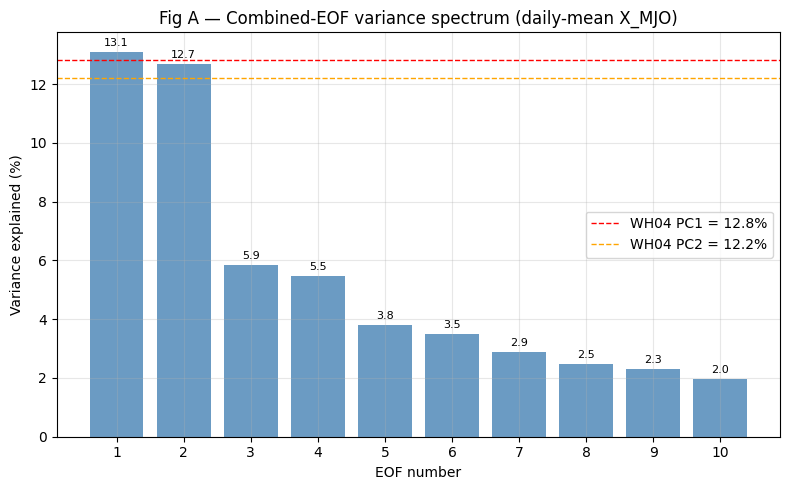

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/fig24A_variance_spectrum.png


In [3]:
# Full eigenvalue spectrum from Pipeline A basis
U_all, S_all, _ = np.linalg.svd(Y_c, full_matrices=False)
var_all = (S_all ** 2) / (S_all ** 2).sum()

fig, ax = plt.subplots(figsize=(8, 5))
k = 10
ax.bar(np.arange(1, k + 1), var_all[:k] * 100, color='steelblue', alpha=0.8)
for i in range(k):
    ax.text(i + 1, var_all[i] * 100 + 0.2, f'{var_all[i]*100:.1f}', ha='center', fontsize=8)
ax.axhline(12.8, color='r', ls='--', lw=1, label='WH04 PC1 = 12.8%')
ax.axhline(12.2, color='orange', ls='--', lw=1, label='WH04 PC2 = 12.2%')
ax.set_xlabel('EOF number'); ax.set_ylabel('Variance explained (%)')
ax.set_title('Fig A — Combined-EOF variance spectrum (daily-mean X_MJO)')
ax.set_xticks(np.arange(1, k + 1)); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
p = f'{PROCESSED_DIR}/fig24A_variance_spectrum.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show(); print('Saved', p)

## Cell 4 — Fig B: EOF1 / EOF2 Longitude Structure (WH04 Fig 2)

Each EOF is reshaped back to `(3, 180)` — one curve per channel vs longitude. EOF1 and EOF2 should be in spatial quadrature (the OLR minimum of EOF2 sits ~¼ wavelength east of EOF1), which is how a standing pair of patterns encodes eastward propagation.

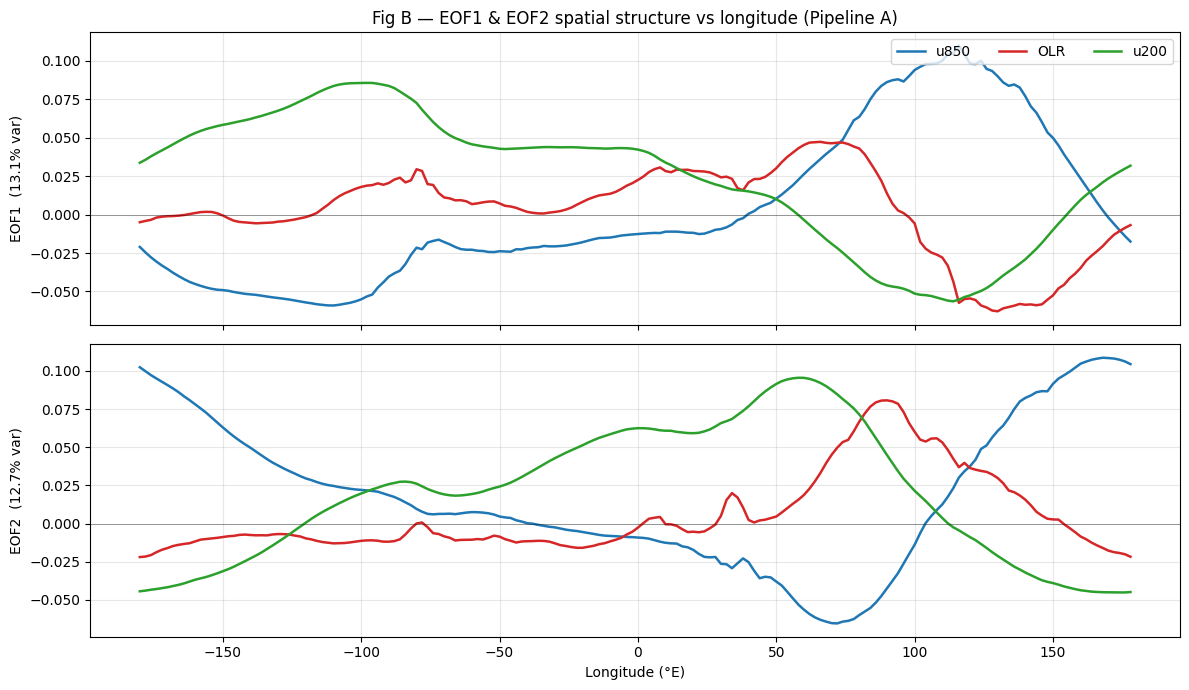

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/fig24B_eof_patterns.png


In [4]:
nlon = len(lons)
eofA_r = eofA.reshape(2, 3, nlon)  # (PC, channel, lon)
colors = {'u850': 'tab:blue', 'OLR': 'tab:red', 'u200': 'tab:green'}

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for row, ax in enumerate(axes):
    for ci, ch in enumerate(CHANNELS):
        ax.plot(lons, eofA_r[row, ci], color=colors[ch], lw=1.8, label=ch)
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_ylabel(f'EOF{row+1}  ({var_all[row]*100:.1f}% var)')
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.legend(loc='upper right', ncol=3)
axes[0].set_title('Fig B — EOF1 & EOF2 spatial structure vs longitude (Pipeline A)')
axes[-1].set_xlabel('Longitude (°E)')
plt.tight_layout()
p = f'{PROCESSED_DIR}/fig24B_eof_patterns.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show(); print('Saved', p)

## Cell 5 — Fig C: PC1 × PC2 Lag-Correlation (WH04 Fig 3)

Cross-correlation of RMM1 and RMM2 vs lag. For an eastward-propagating mode the curve is antisymmetric with an extremum near **±10 days** (RMM1 leads RMM2 by ~¼ cycle). A flat curve would mean the two PCs are not a coupled oscillation.

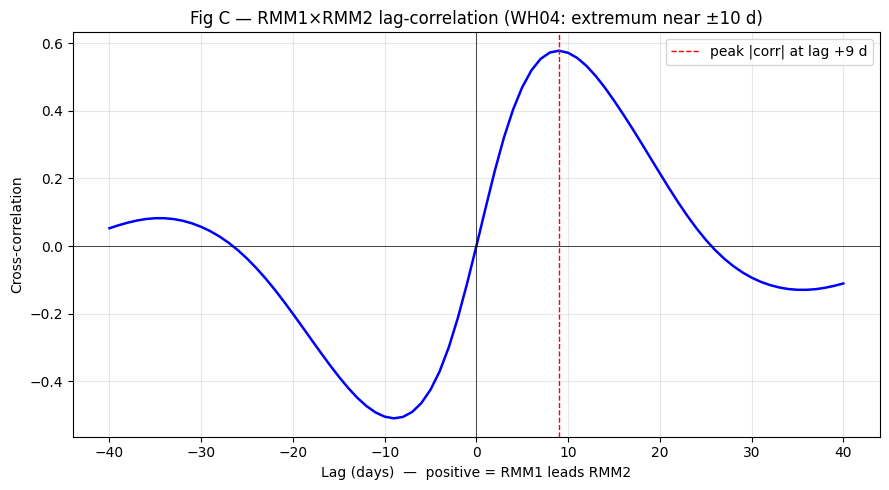

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/fig24C_lag_correlation.png  | peak |corr| = 0.577 at lag +9 d


In [5]:
def lag_corr(x, y, max_lag=40):
    x = (x - x.mean()) / x.std(); y = (y - y.mean()) / y.std()
    n = len(x); lags = np.arange(-max_lag, max_lag + 1); out = []
    for L in lags:
        if L < 0:
            out.append(np.mean(x[-L:] * y[:n + L]))
        elif L > 0:
            out.append(np.mean(x[:n - L] * y[L:]))
        else:
            out.append(np.mean(x * y))
    return lags, np.array(out)

lags, lc = lag_corr(pcA_std[:, 0], pcA_std[:, 1], max_lag=40)
peak_lag = lags[np.argmax(np.abs(lc))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lags, lc, 'b-', lw=1.8)
ax.axvline(0, color='k', lw=0.5); ax.axhline(0, color='k', lw=0.5)
ax.axvline(peak_lag, color='r', ls='--', lw=1, label=f'peak |corr| at lag {peak_lag:+d} d')
ax.set_xlabel('Lag (days)  —  positive = RMM1 leads RMM2')
ax.set_ylabel('Cross-correlation')
ax.set_title('Fig C — RMM1×RMM2 lag-correlation (WH04: extremum near ±10 d)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
p = f'{PROCESSED_DIR}/fig24C_lag_correlation.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved {p}  | peak |corr| = {np.abs(lc).max():.3f} at lag {peak_lag:+d} d')

## Cell 6 — Fig D: RMM Power Spectra (WH04 Fig 4)

Power spectral density of RMM1 and RMM2. A broad peak in the **30–80 day** band is the MJO signature; if the daily-average preprocessing destroyed the intraseasonal variance this peak would be absent.

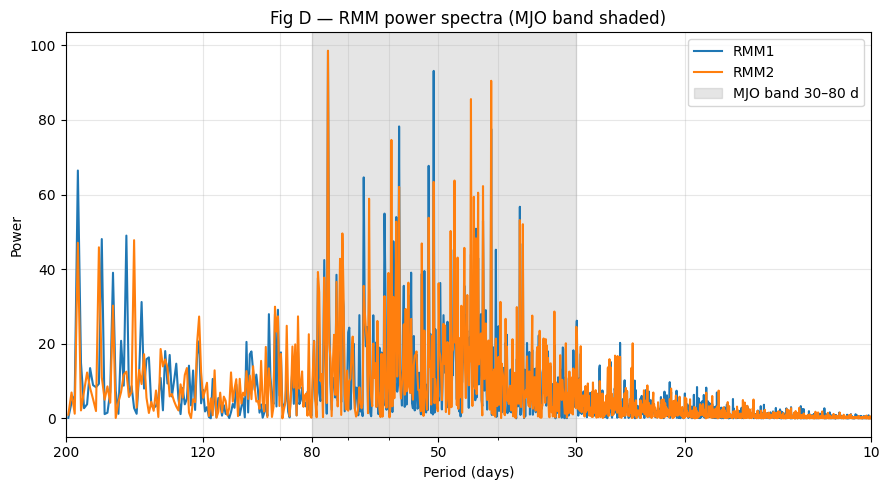

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/fig24D_power_spectra.png


In [6]:
def psd(x, fs=1.0):
    x = x - x.mean()
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    power = np.abs(np.fft.rfft(x)) ** 2 / len(x)
    return freqs, power

fig, ax = plt.subplots(figsize=(9, 5))
for j, (lab, col) in enumerate([('RMM1', 'tab:blue'), ('RMM2', 'tab:orange')]):
    f, P = psd(pcA_std[:, j])
    with np.errstate(divide='ignore'):
        period = np.where(f > 0, 1.0 / f, np.inf)
    m = (period >= 10) & (period <= 200)
    ax.plot(period[m], P[m], color=col, lw=1.5, label=lab)
ax.axvspan(30, 80, color='grey', alpha=0.2, label='MJO band 30–80 d')
ax.set_xlabel('Period (days)'); ax.set_ylabel('Power')
ax.set_xscale('log'); ax.set_xlim(200, 10)
ax.set_xticks([10, 20, 30, 50, 80, 120, 200])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_title('Fig D — RMM power spectra (MJO band shaded)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
p = f'{PROCESSED_DIR}/fig24D_power_spectra.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show(); print('Saved', p)

## Cell 7 — Fig E: RMM1–RMM2 Phase Diagram (WH04 Fig 7)

The iconic MJO phase-space plot. x = RMM1, y = RMM2; the plane is split into 8 phase octants; the unit circle is the active-MJO threshold (amplitude = √(RMM1²+RMM2²) ≥ 1). Our PCs (left) beside the official BoM RMM (right). The labeled regions mark where MJO convection is centered in each phase.

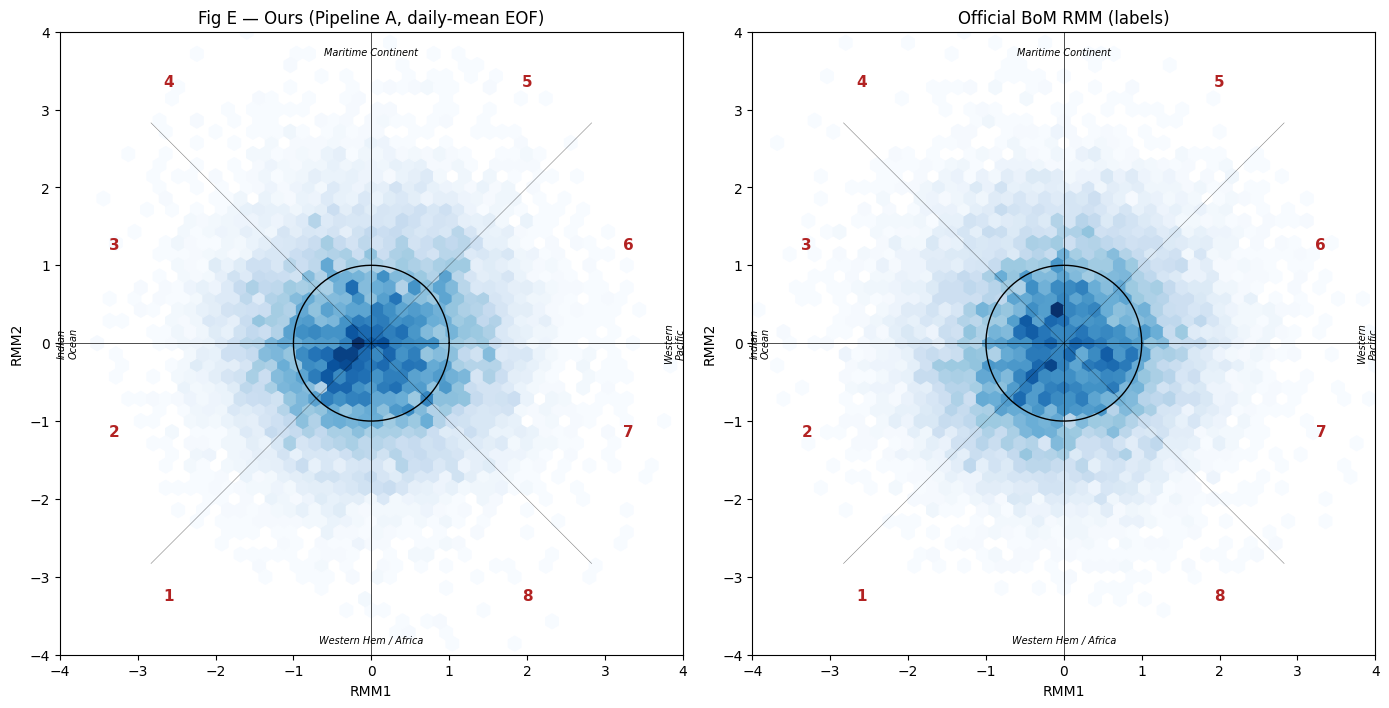

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/fig24E_phase_diagram.png


In [7]:
def phase_diagram(ax, r1, r2, title):
    ax.hexbin(r1, r2, gridsize=50, cmap='Blues', mincnt=1, extent=(-4, 4, -4, 4))
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(th), np.sin(th), 'k-', lw=1)            # unit circle
    for ang in np.arange(0, 360, 45):                       # octant rays
        a = np.deg2rad(ang)
        ax.plot([0, 4 * np.cos(a)], [0, 4 * np.sin(a)], 'k-', lw=0.4, alpha=0.5)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_xlabel('RMM1'); ax.set_ylabel('RMM2'); ax.set_title(title)
    # phase numbers and region labels (WH04 convention)
    pos = {1: (-2.6, -3.3), 2: (-3.3, -1.2), 3: (-3.3, 1.2), 4: (-2.6, 3.3),
           5: (2.0, 3.3), 6: (3.3, 1.2), 7: (3.3, -1.2), 8: (2.0, -3.3)}
    for ph, (px, py) in pos.items():
        ax.text(px, py, str(ph), fontsize=11, fontweight='bold', color='firebrick', ha='center')
    ax.text(0, -3.85, 'Western Hem / Africa', ha='center', fontsize=7, style='italic')
    ax.text(-3.9, 0, 'Indian\nOcean', va='center', ha='center', fontsize=7, style='italic', rotation=90)
    ax.text(0, 3.7, 'Maritime Continent', ha='center', fontsize=7, style='italic')
    ax.text(3.9, 0, 'Western\nPacific', va='center', ha='center', fontsize=7, style='italic', rotation=90)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
phase_diagram(axes[0], pcA_std[:, 0], pcA_std[:, 1], 'Fig E — Ours (Pipeline A, daily-mean EOF)')
phase_diagram(axes[1], bom[:, 0], bom[:, 1], 'Official BoM RMM (labels)')
plt.tight_layout()
p = f'{PROCESSED_DIR}/fig24E_phase_diagram.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show(); print('Saved', p)

## Cell 8 — Fig F: RMM Timeseries — Ours vs BoM

Top two panels: full record, monthly-mean smoothed, ours (solid) vs BoM (dashed). Bottom two panels: daily resolution for one strong El Niño year and one strong La Niña year (auto-selected from the ENSO labels).

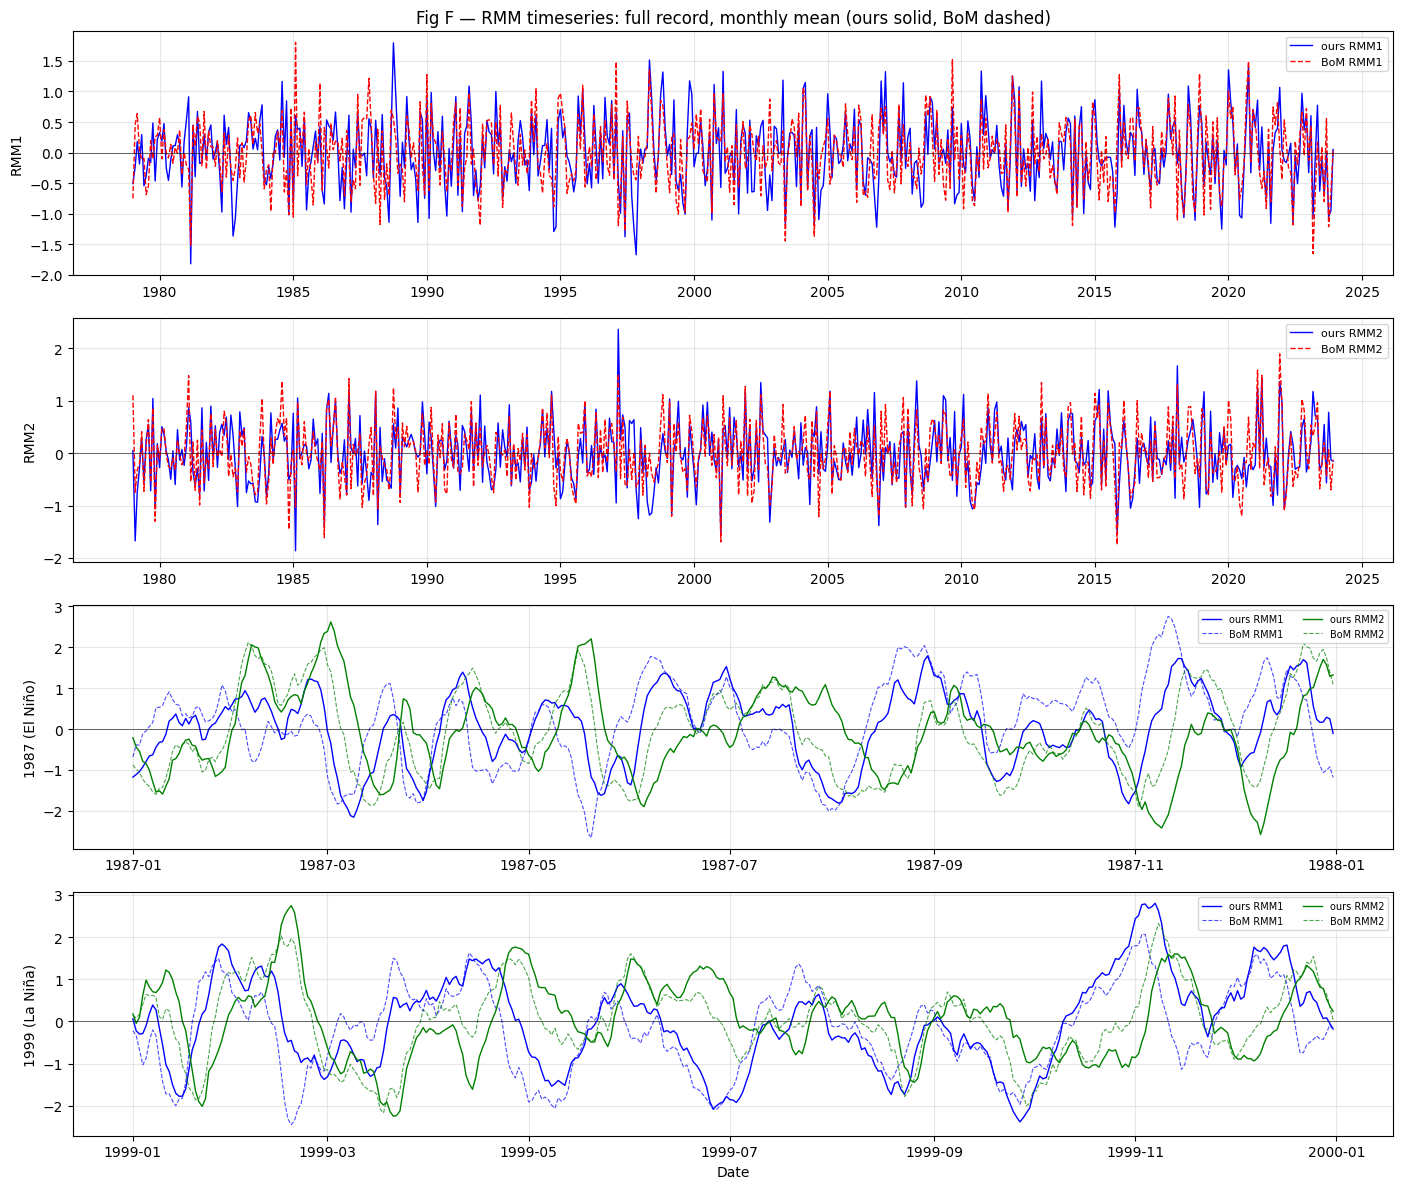

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/fig24F_rmm_timeseries.png  | zoom years: El Nino=1987, La Nina=1999


In [8]:
dts = labels['date']
dfp = pd.DataFrame({'date': dts,
                    'our1': pcA_std[:, 0], 'our2': pcA_std[:, 1],
                    'bom1': bom[:, 0], 'bom2': bom[:, 1],
                    'enso': labels['enso_category'].values})
dfp['ym'] = dfp['date'].dt.to_period('M')
monthly = dfp.groupby('ym')[['our1', 'our2', 'bom1', 'bom2']].mean()
mdates = monthly.index.to_timestamp()

# pick a representative El Nino and La Nina year (most days in that category)
dfp['yr'] = dfp['date'].dt.year
yr_en = dfp[dfp.enso == 'El Nino'].yr.value_counts().idxmax() if (dfp.enso == 'El Nino').any() else dfp.yr.iloc[-1]
yr_ln = dfp[dfp.enso == 'La Nina'].yr.value_counts().idxmax() if (dfp.enso == 'La Nina').any() else dfp.yr.iloc[0]

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
for ax, comp, lab in zip(axes[:2], ['1', '2'], ['RMM1', 'RMM2']):
    ax.plot(mdates, monthly[f'our{comp}'], 'b-', lw=1.0, label=f'ours {lab}')
    ax.plot(mdates, monthly[f'bom{comp}'], 'r--', lw=1.0, label=f'BoM {lab}')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel(lab); ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3)
axes[0].set_title('Fig F — RMM timeseries: full record, monthly mean (ours solid, BoM dashed)')

for ax, yr, tag in zip(axes[2:], [yr_en, yr_ln], ['El Niño', 'La Niña']):
    sub = dfp[dfp.yr == yr]
    ax.plot(sub.date, sub.our1, 'b-', lw=1.0, label='ours RMM1')
    ax.plot(sub.date, sub.bom1, 'b--', lw=0.8, alpha=0.7, label='BoM RMM1')
    ax.plot(sub.date, sub.our2, 'g-', lw=1.0, label='ours RMM2')
    ax.plot(sub.date, sub.bom2, 'g--', lw=0.8, alpha=0.7, label='BoM RMM2')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel(f'{yr} ({tag})'); ax.legend(loc='upper right', ncol=2, fontsize=7); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Date')
plt.tight_layout()
p = f'{PROCESSED_DIR}/fig24F_rmm_timeseries.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved {p}  | zoom years: El Nino={yr_en}, La Nina={yr_ln}')

## Cell 9 — Fig G: Longitude-Profile Phase Composites (substitute for WH04 Fig 8)

WH04 Fig 8 shows lat–lon composite maps by phase. Our preprocessing collapsed latitude (15°S–15°N average), so we instead composite the **longitude profiles** of OLR and u850 for each of the 8 phases (active days only). The OLR minimum (enhanced convection) should march eastward as phase increases — the same eastward propagation seen in nb13 Cell 11, now keyed to *our* RMM phase rather than the label phase.

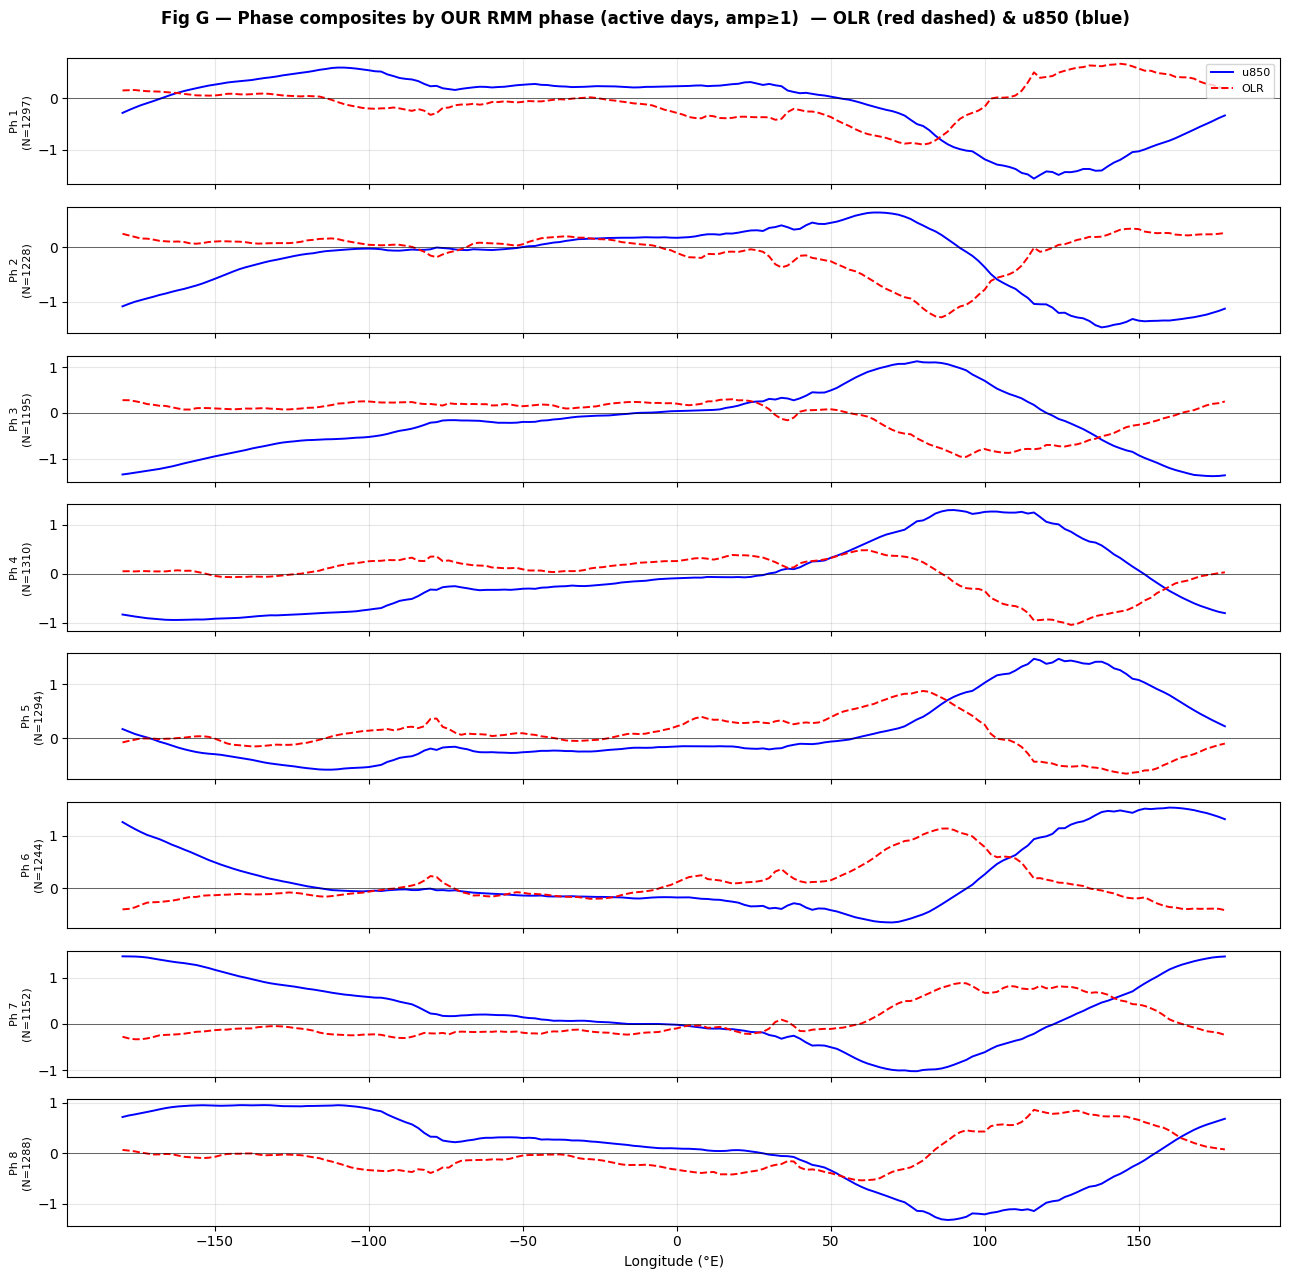

Saved /content/drive/MyDrive/BSISO_SSL_Project/MJO/data/processed/fig24G_phase_composites.png
Phase agreement (both active): exact=25.1%  within±1=97.9%


In [9]:
# Build phase/amplitude FROM OUR PCs (not the labels) to test our index end-to-end.
our_amp = np.sqrt(pcA_std[:, 0] ** 2 + pcA_std[:, 1] ** 2)
# WH04 phase definition: angle of (RMM1, RMM2); phases 1..8 counterclockwise
ang = np.arctan2(pcA_std[:, 1], pcA_std[:, 0])               # (-pi, pi]
our_phase = (np.floor((ang + np.pi) / (np.pi / 4)) % 8).astype(int) + 1
active = our_amp >= 1.0

u850_field = X_MJO[:, 0, 0, :]   # (N, 180)
olr_field  = X_MJO[:, 1, 0, :]

fig, axes = plt.subplots(8, 1, figsize=(13, 13), sharex=True)
fig.suptitle('Fig G — Phase composites by OUR RMM phase (active days, amp≥1)  '
             '— OLR (red dashed) & u850 (blue)', fontsize=12, fontweight='bold')
for ax, ph in zip(axes, range(1, 9)):
    m = active & (our_phase == ph)
    if m.sum() == 0:
        ax.set_ylabel(f'Ph {ph}\n(N=0)'); continue
    ax.plot(lons, u850_field[m].mean(0), 'b-', lw=1.4, label='u850')
    ax.plot(lons, olr_field[m].mean(0), 'r--', lw=1.4, label='OLR')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_ylabel(f'Ph {ph}\n(N={int(m.sum())})', fontsize=8)
    ax.grid(True, alpha=0.3)
    if ph == 1:
        ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Longitude (°E)')
plt.tight_layout(rect=[0, 0, 1, 0.98])
p = f'{PROCESSED_DIR}/fig24G_phase_composites.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show(); print('Saved', p)

# agreement between our phase and BoM phase on active days
if 'phase' in labels.columns:
    bom_active = labels['amplitude'].values >= 1.0
    both = active & bom_active
    agree = (our_phase[both] == labels['phase'].values[both]).mean()
    within1 = (np.abs(((our_phase[both] - labels['phase'].values[both] + 4) % 8) - 4) <= 1).mean()
    print(f'Phase agreement (both active): exact={agree*100:.1f}%  within±1={within1*100:.1f}%')

## Cell 9b — Fig H: Quantitative Agreement, Ours (Rotation-Aligned) vs BoM RMM

Turns "looks similar" into numbers, using the **rotation-aligned** `pcA_rot` (Cell 2b) so a benign basis rotation doesn't masquerade as disagreement. Four panels: (a,b) hexbin ours vs BoM for RMM1/RMM2 with Pearson r, slope, RMSE (σ); (c) amplitude agreement (rotation-invariant); (d) 8×8 phase confusion matrix on days active in both indices (exact + within-±1). Also prints **ENSO-stratified** corr — does agreement depend on El Niño / La Niña? Compare the headline r here against the raw 0.785/0.793 from Cell 2: if it jumps toward 0.9 and canonical corr (Cell 2b) is high, our MJO subspace matches BoM and the gap was just rotation.

In [ ]:
from scipy.stats import pearsonr

# Use the ROTATION-ALIGNED PCs (pcA_rot from Cell 2b) for a fair ours-vs-BoM comparison.
our_r1, our_r2 = pcA_rot[:, 0], pcA_rot[:, 1]
bom_r1, bom_r2 = bom[:, 0], bom[:, 1]
our_amp_h = np.sqrt(our_r1 ** 2 + our_r2 ** 2)          # rotation-invariant
ang_h = np.arctan2(our_r2, our_r1)
our_phase_h = (np.floor((ang_h + np.pi) / (np.pi / 4)) % 8).astype(int) + 1
bom_amp_h  = labels['amplitude'].values
bom_phase_h = labels['phase'].values.astype(int)
enso_h = labels['enso_category'].values

hr1 = pearsonr(our_r1, bom_r1)[0]; hr2 = pearsonr(our_r2, bom_r2)[0]
rmse1 = float(np.sqrt(np.mean((our_r1 - bom_r1) ** 2)))
rmse2 = float(np.sqrt(np.mean((our_r2 - bom_r2) ** 2)))
slope1 = float(np.polyfit(bom_r1, our_r1, 1)[0]); slope2 = float(np.polyfit(bom_r2, our_r2, 1)[0])
r_amp = pearsonr(our_amp_h, bom_amp_h)[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

def scatter_panel(ax, x, y, r, rmse, slope, name):
    ax.hexbin(x, y, gridsize=60, cmap='Blues', mincnt=1)
    lim = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lim, lim, 'r-', lw=1, label='1:1')
    ax.set_xlabel(f'BoM {name}'); ax.set_ylabel(f'ours {name}')
    ax.set_title(f'{name}: r={r:.3f}, slope={slope:.2f}, RMSE={rmse:.2f}σ', fontsize=11)
    ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.3)

scatter_panel(axes[0, 0], bom_r1, our_r1, hr1, rmse1, slope1, 'RMM1')
scatter_panel(axes[0, 1], bom_r2, our_r2, hr2, rmse2, slope2, 'RMM2')

# (c) amplitude agreement
ax = axes[1, 0]
ax.hexbin(bom_amp_h, our_amp_h, gridsize=60, cmap='Greens', mincnt=1)
lim = [0, max(bom_amp_h.max(), our_amp_h.max())]
ax.plot(lim, lim, 'r-', lw=1, label='1:1')
ax.axhline(1, color='grey', ls=':', lw=0.8); ax.axvline(1, color='grey', ls=':', lw=0.8)
ax.set_xlabel('BoM amplitude'); ax.set_ylabel('ours amplitude')
ax.set_title(f'Amplitude: r={r_amp:.3f}', fontsize=11)
ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.3)

# (d) 8x8 phase confusion matrix on days active in BOTH indices
both = (our_amp_h >= 1.0) & (bom_amp_h >= 1.0)
cm = np.zeros((8, 8))
for b, o in zip(bom_phase_h[both], our_phase_h[both]):
    if 1 <= b <= 8 and 1 <= o <= 8:
        cm[b - 1, o - 1] += 1
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)
ax = axes[1, 1]
im = ax.imshow(cm_norm, cmap='viridis', vmin=0, vmax=1, origin='lower', extent=[0.5, 8.5, 0.5, 8.5])
ax.set_xlabel('our phase'); ax.set_ylabel('BoM phase')
exact = float((our_phase_h[both] == bom_phase_h[both]).mean())
within1 = float((np.abs(((our_phase_h[both] - bom_phase_h[both] + 4) % 8) - 4) <= 1).mean())
ax.set_title(f'Phase confusion (both active)\nexact={exact*100:.1f}%  within±1={within1*100:.1f}%', fontsize=11)
ax.set_xticks(range(1, 9)); ax.set_yticks(range(1, 9))
plt.colorbar(im, ax=ax, fraction=0.046, label='row-normalized count')

plt.suptitle('Fig H — Quantitative agreement: ours (rotation-aligned) vs BoM RMM',
             fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.98])
p = f'{PROCESSED_DIR}/fig24H_agreement.png'
plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show(); print('Saved', p)

# ENSO-stratified correlation (rotation-aligned)
print('\nENSO-stratified corr(ours_rot, BoM):')
enso_corr = {}
for cat in ['El Nino', 'Neutral', 'La Nina']:
    m = enso_h == cat
    if m.sum() < 10:
        continue
    cc1 = pearsonr(our_r1[m], bom_r1[m])[0]; cc2 = pearsonr(our_r2[m], bom_r2[m])[0]
    enso_corr[cat] = [float(cc1), float(cc2)]
    print(f'  {cat:8s} (n={m.sum():5d}): RMM1 r={cc1:.3f}  RMM2 r={cc2:.3f}')

agreement = {
    'rotation_aligned': True, 'procrustes_angle_deg': rot_angle,
    'canonical_corr': [float(canon[0]), float(canon[1])],
    'corr_rmm1': float(hr1), 'corr_rmm2': float(hr2),
    'rmse_rmm1_sigma': rmse1, 'rmse_rmm2_sigma': rmse2,
    'slope_rmm1': slope1, 'slope_rmm2': slope2,
    'corr_amplitude': float(r_amp),
    'phase_exact_pct': exact * 100, 'phase_within1_pct': within1 * 100,
    'n_both_active': int(both.sum()), 'enso_stratified_corr': enso_corr,
}
with open(f'{PROCESSED_DIR}/fig24H_agreement.json', 'w') as f:
    json.dump(agreement, f, indent=2)
print('\nSaved fig24H_agreement.json')
print(f"Headline (rotation-aligned): RMM1 r={hr1:.3f}, RMM2 r={hr2:.3f}, amp r={r_amp:.3f}, "
      f"phase exact {exact*100:.0f}% / ±1 {within1*100:.0f}%  | canonical {canon[0]:.2f},{canon[1]:.2f}")

## Cell 10 — Save Outputs + Metadata

In [10]:
np.save(f'{PROCESSED_DIR}/mjo_rmm_own_pcs.npy',  pcA_std.astype(np.float32))
np.save(f'{PROCESSED_DIR}/mjo_rmm_wh04_pcs.npy', pcB_std.astype(np.float32))
np.save(f'{PROCESSED_DIR}/mjo_eof_patterns.npy', eofA.reshape(2, 3, nlon).astype(np.float32))

meta = {
    'n_days': int(N),
    'channel_order': CHANNELS,
    'meridional_band': '15S-15N (from nb13)',
    'pipelineA_var_pct': [float(varA[0] * 100), float(varA[1] * 100)],
    'pipelineB_var_pct': [float(varB[0] * 100), float(varB[1] * 100)],
    'corr_with_bom': {
        'A': {'rmm1': float(cA1), 'rmm2': float(cA2)},
        'B': {'rmm1': float(cB1), 'rmm2': float(cB2)},
    },
    'sign_align_A': logA, 'sign_align_B': logB,
    'lag_corr_peak_day': int(peak_lag),
    'zoom_years': {'el_nino': int(yr_en), 'la_nina': int(yr_ln)},
    'wh04_benchmark_var_pct': [12.8, 12.2],
}
with open(f'{PROCESSED_DIR}/mjo_rmm_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved arrays + metadata:')
for fn in ['mjo_rmm_own_pcs.npy', 'mjo_rmm_wh04_pcs.npy', 'mjo_eof_patterns.npy', 'mjo_rmm_metadata.json']:
    fp = f'{PROCESSED_DIR}/{fn}'
    print(f'  {fn:28s} ({os.path.getsize(fp)/1e3:.1f} KB)')
print('\nMetadata:'); print(json.dumps(meta, indent=2))

Saved arrays + metadata:
  mjo_rmm_own_pcs.npy          (131.6 KB)
  mjo_rmm_wh04_pcs.npy         (131.6 KB)
  mjo_eof_patterns.npy         (4.4 KB)
  mjo_rmm_metadata.json        (0.8 KB)

Metadata:
{
  "n_days": 16436,
  "channel_order": [
    "u850",
    "OLR",
    "u200"
  ],
  "meridional_band": "15S-15N (from nb13)",
  "pipelineA_var_pct": [
    13.102931149032681,
    12.692848170737673
  ],
  "pipelineB_var_pct": [
    13.117832168454926,
    12.723852976791145
  ],
  "corr_with_bom": {
    "A": {
      "rmm1": 0.7848642445291991,
      "rmm2": 0.7927835751679031
    },
    "B": {
      "rmm1": 0.678413366165032,
      "rmm2": 0.708229871197027
    }
  },
  "sign_align_A": {
    "swapped": false,
    "flipped_pc1": true,
    "flipped_pc2": true
  },
  "sign_align_B": {
    "swapped": true,
    "flipped_pc1": false,
    "flipped_pc2": false
  },
  "lag_corr_peak_day": 9,
  "zoom_years": {
    "el_nino": 1987,
    "la_nina": 1999
  },
  "wh04_benchmark_var_pct": [
    12.8,
    1

---
## Done!

Seven figures written to `MJO/data/processed/`:
```
fig24A_variance_spectrum.png    (WH04 Fig 1)
fig24B_eof_patterns.png         (WH04 Fig 2)
fig24C_lag_correlation.png      (WH04 Fig 3)
fig24D_power_spectra.png        (WH04 Fig 4)
fig24E_phase_diagram.png        (WH04 Fig 7)
fig24F_rmm_timeseries.png
fig24G_phase_composites.png     (substitute for WH04 Fig 8)
```

**How to read the comparison:**
- **Fig A** — if PC1/PC2 ≈ 12–13% and pair up above PC3, the daily-mean EOF reproduced the canonical MJO leading pair.
- **Fig B** — EOF1/EOF2 in quadrature confirms the propagating structure survived daily averaging.
- **Fig C** — extremum near ±10 d confirms RMM1 leads RMM2 (eastward propagation).
- **Fig D** — a 30–80 day spectral peak confirms intraseasonal variance was retained.
- **Fig E / metadata corr** — high corr(ours, BoM) > 0.9 means our daily-mean RMM matches the official index.
- **Fig G + phase agreement %** — tests our end-to-end index (EOF → phase) against the BoM phase label.

Send the printed correlations + the figures back to chat and we'll diagnose any deviation from WH04 / BoM.

---
*DDCS Project | jh9141@nyu.edu*